In [1]:
%pip install tensorflow==2.4.1 tensorflow-gpu==2.4.1 opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: C:\Users\siddh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import cv2
import os
import random
import numpy as np
from matplotlib import pyplot as plt
# Import tensorflow dependencies - Functional API
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten
import tensorflow as tf

In [3]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [7]:
# Setup paths
POS_PATH = os.path.join('data', 'positive')
NEG_PATH = os.path.join('data', 'negative')
ANC_PATH = os.path.join('data', 'anchor')
# Make the directories
os.makedirs(POS_PATH)
os.makedirs(NEG_PATH)
os.makedirs(ANC_PATH)

FileExistsError: [WinError 183] Cannot create a file when that file already exists: 'data\\positive'

In [8]:
for directory in os.listdir('lfw'):
    for file in os.listdir(os.path.join('lfw', directory)):
        EX_PATH = os.path.join('lfw', directory, file)
        NEW_PATH = os.path.join(NEG_PATH, file)
        os.replace(EX_PATH, NEW_PATH)

In [4]:
import uuid

In [5]:
cap = cv2.VideoCapture(0)

In [9]:
# Establish a connection to the webcam
cap = cv2.VideoCapture(0)
while cap.isOpened(): 
    ret, frame = cap.read()
   
    # Cut down frame to 250x250px
    frame = frame[120:120+250,200:200+250, :]
    
    # Collect anchors 
    if cv2.waitKey(1) & 0XFF == ord('a'):
        # Create the unique file path 
        imgname = os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))
        # Write out anchor image
        cv2.imwrite(imgname, frame)
    
    # Collect positives
    if cv2.waitKey(1) & 0XFF == ord('p'):
        # Create the unique file path 
        imgname = os.path.join(POS_PATH, '{}.jpg'.format(uuid.uuid1()))
        # Write out positive image
        cv2.imwrite(imgname, frame)
    
    # Show image back to screen
    cv2.imshow('Image Collection', frame)
    
    # Breaking gracefully
    if cv2.waitKey(1) & 0XFF == ord('q'):
        break
        
# Release the webcam
cap.release()
# Close the image show frame
cv2.destroyAllWindows()

In [10]:
anchor = tf.data.Dataset.list_files(ANC_PATH+'\*.jpg').take(300)
positive = tf.data.Dataset.list_files(POS_PATH+'\*.jpg').take(300)
negative = tf.data.Dataset.list_files(NEG_PATH+'\*.jpg').take(300)

In [11]:
dir_test = anchor.as_numpy_iterator()


In [12]:
def preprocess(file_path):
    
    # Read in image from file path
    byte_img = tf.io.read_file(file_path)
    # Load in the image 
    img = tf.io.decode_jpeg(byte_img)
    
    # Preprocessing steps - resizing the image to be 100x100x3
    img = tf.image.resize(img, (100,100))
    # Scale image to be between 0 and 1 
    img = img / 255.0
    
    # Return image
    return img

In [13]:
print(dir_test.next())


b'data\\anchor\\411eafdb-dbf0-11ef-b34e-401a582ecf56.jpg'


In [14]:
img = preprocess('data\\anchor\\7a4ae10a-dbf0-11ef-be8f-401a582ecf56.jpg')


In [15]:
img.numpy().max() 


0.8982843

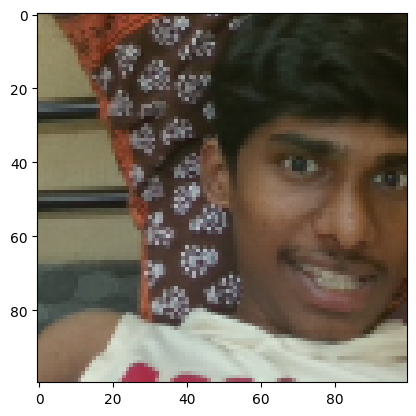

In [17]:
plt.imshow(img)

In [18]:
dataset.map(preprocess)

NameError: name 'dataset' is not defined

In [19]:
positives = tf.data.Dataset.zip((anchor, positive, tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor)))))
negatives = tf.data.Dataset.zip((anchor, negative, tf.data.Dataset.from_tensor_slices(tf.zeros(len(anchor)))))
data = positives.concatenate(negatives)

In [20]:
samples = data.as_numpy_iterator()

In [21]:
exampple = samples.next()

In [22]:
exampple

(b'data\\anchor\\799a0de1-dbf0-11ef-85cb-401a582ecf56.jpg',
 b'data\\positive\\eac08ffa-dbf0-11ef-a462-401a582ecf56.jpg',
 1.0)

In [23]:
def preprocess_twin(input_img, validation_img, label):
    return(preprocess(input_img), preprocess(validation_img), label)

In [24]:
res = preprocess_twin(*exampple)

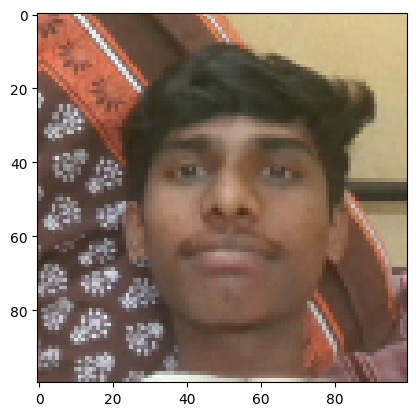

In [25]:
plt.imshow(res[1])

In [26]:
res[2]

1.0

In [27]:
data = data.map(preprocess_twin)
data = data.cache()
data = data.shuffle(buffer_size=1024)

In [28]:
train_data = data.take(round(len(data)*.7))
train_data = train_data.batch(16)
train_data = train_data.prefetch(8)

In [30]:
test_data = data.skip(round(len(data)*.7))
test_data = test_data.take(round(len(data)*.3))
test_data = test_data.batch(16)
test_data = test_data.prefetch(8)

In [31]:
inp = Input(shape=(100,100,3), name='input_image')

In [32]:
c1 = Conv2D(64, (10,10), activation='relu')(inp)

In [33]:
m1 = MaxPooling2D(64, (2,2), padding='same')(c1)

In [34]:
c2 = Conv2D(128, (7,7), activation='relu')(m1)
m2 = MaxPooling2D(64, (2,2), padding='same')(c2)

In [35]:
c3 = Conv2D(128, (4,4), activation='relu')(m2)
m3 = MaxPooling2D(64, (2,2), padding='same')(c3)

In [36]:
c4 = Conv2D(256, (4,4), activation='relu')(m3)
f1 = Flatten()(c4)
d1 = Dense(4096, activation='sigmoid')(f1)

In [37]:
mod = Model(inputs=[inp], outputs=[d1], name='embedding')

In [38]:
mod.summary()


Model: "embedding"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_image (InputLayer)     [(None, 100, 100, 3)]     0         
_________________________________________________________________
conv2d (Conv2D)              (None, 91, 91, 64)        19264     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 46, 46, 64)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 40, 40, 128)       401536    
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 20, 20, 128)       0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 17, 17, 128)       262272    
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 9, 9, 128)         0 

In [39]:
def make_embedding(): 
    inp = Input(shape=(100,100,3), name='input_image')
    
    # First block
    c1 = Conv2D(64, (10,10), activation='relu')(inp)
    m1 = MaxPooling2D(64, (2,2), padding='same')(c1)
    
    # Second block
    c2 = Conv2D(128, (7,7), activation='relu')(m1)
    m2 = MaxPooling2D(64, (2,2), padding='same')(c2)
    
    # Third block 
    c3 = Conv2D(128, (4,4), activation='relu')(m2)
    m3 = MaxPooling2D(64, (2,2), padding='same')(c3)
    
    # Final embedding block
    c4 = Conv2D(256, (4,4), activation='relu')(m3)
    f1 = Flatten()(c4)
    d1 = Dense(4096, activation='sigmoid')(f1)
    
    
    return Model(inputs=[inp], outputs=[d1], name='embedding')

In [40]:
embedding = make_embedding()


In [41]:
embedding.summary()


Model: "embedding"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_image (InputLayer)     [(None, 100, 100, 3)]     0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 91, 91, 64)        19264     
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 46, 46, 64)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 40, 40, 128)       401536    
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 20, 20, 128)       0         
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 17, 17, 128)       262272    
_________________________________________________________________
max_pooling2d_5 (MaxPooling2 (None, 9, 9, 128)         0 

In [42]:
# Siamese L1 Distance class
class L1Dist(Layer):
    
    # Init method - inheritance
    def __init__(self, **kwargs):
        super().__init__()
       
    # Magic happens here - similarity calculation
    def call(self, input_embedding, validation_embedding):
        return tf.math.abs(input_embedding - validation_embedding)

In [43]:
l1 = L1Dist()


In [44]:
l1(anchor_embedding, validation_embedding)


NameError: name 'anchor_embedding' is not defined

In [45]:
input_image = Input(name='input_img', shape=(100,100,3))
validation_image = Input(name='validation_img', shape=(100,100,3))

In [46]:
inp_embedding = embedding(input_image)
val_embedding = embedding(validation_image)

In [47]:
siamese_layer = L1Dist()

In [48]:
distances = siamese_layer(inp_embedding, val_embedding)


In [49]:
classifier = Dense(1, activation='sigmoid')(distances)


In [50]:
classifier


<KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'dense_2')>

In [51]:
siamese_network = Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')


In [52]:
siamese_network.summary()


Model: "SiameseNetwork"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_img (InputLayer)          [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
validation_img (InputLayer)     [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
embedding (Functional)          (None, 4096)         38960448    input_img[0][0]                  
                                                                 validation_img[0][0]             
__________________________________________________________________________________________________
l1_dist_1 (L1Dist)              (None, 4096)         0           embedding[0][0]     

In [53]:
def make_siamese_model(): 
    
    # Anchor image input in the network
    input_image = Input(name='input_img', shape=(100,100,3))
    
    # Validation image in the network 
    validation_image = Input(name='validation_img', shape=(100,100,3))
    
    # Combine siamese distance components
    siamese_layer = L1Dist()
    siamese_layer._name = 'distance'
    distances = siamese_layer(embedding(input_image), embedding(validation_image))
    
    # Classification layer 
    classifier = Dense(1, activation='sigmoid')(distances)
    
    return Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

In [54]:
siamese_model = make_siamese_model()


In [55]:
siamese_model.summary()


Model: "SiameseNetwork"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_img (InputLayer)          [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
validation_img (InputLayer)     [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
embedding (Functional)          (None, 4096)         38960448    input_img[0][0]                  
                                                                 validation_img[0][0]             
__________________________________________________________________________________________________
distance (L1Dist)               (None, 4096)         0           embedding[2][0]     

In [56]:
binary_cross_loss = tf.losses.BinaryCrossentropy()


In [57]:
opt = tf.keras.optimizers.Adam(1e-4) # 0.0001


In [58]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
checkpoint = tf.train.Checkpoint(opt=opt, siamese_model=siamese_model)

In [59]:
test_batch = train_data.as_numpy_iterator()


In [60]:
batch_1 = test_batch.next()


In [61]:
X = batch_1[:2]


In [62]:
y = batch_1[2]


In [63]:
y


array([0., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0.],
      dtype=float32)

In [64]:
tf.losses.BinaryCrossentropy??

Init signature:
tf.losses.BinaryCrossentropy(
    from_logits=False,
    label_smoothing=0,
    reduction='auto',
    name='binary_crossentropy',
)
Source:        
class BinaryCrossentropy(LossFunctionWrapper):
  """Computes the cross-entropy loss between true labels and predicted labels.

  Use this cross-entropy loss when there are only two label classes (assumed to
  be 0 and 1). For each example, there should be a single floating-point value
  per prediction.

  In the snippet below, each of the four examples has only a single
  floating-pointing value, and both `y_pred` and `y_true` have the shape
  `[batch_size]`.

  Standalone usage:

  >>> y_true = [[0., 1.], [0., 0.]]
  >>> y_pred = [[0.6, 0.4], [0.4, 0.6]]
  >>> # Using 'auto'/'sum_over_batch_size' reduction type.
  >>> bce = tf.keras.losses.BinaryCrossentropy()
  >>> bce(y_true, y_pred).numpy()
  0.815

  >>> # Calling with 'sample_weight'.
  >>> bce(y_true, y_pred, sample_weight=[1, 0]).numpy()
  0.458

   >>> # Using 'sum'

In [65]:
@tf.function
def train_step(batch):
    
    # Record all of our operations 
    with tf.GradientTape() as tape:     
        # Get anchor and positive/negative image
        X = batch[:2]
        # Get label
        y = batch[2]
        
        # Forward pass
        yhat = siamese_model(X, training=True)
        # Calculate loss
        loss = binary_cross_loss(y, yhat)
    print(loss)
        
    # Calculate gradients
    grad = tape.gradient(loss, siamese_model.trainable_variables)
    
    # Calculate updated weights and apply to siamese model
    opt.apply_gradients(zip(grad, siamese_model.trainable_variables))
    
    # Return loss
    return loss

In [66]:
def train(data, EPOCHS):
    # Loop through epochs
    for epoch in range(1, EPOCHS+1):
        print('\n Epoch {}/{}'.format(epoch, EPOCHS))
        progbar = tf.keras.utils.Progbar(len(data))
        
        # Loop through each batch
        for idx, batch in enumerate(data):
            # Run train step here
            train_step(batch)
            progbar.update(idx+1)
        
        # Save checkpoints
        if epoch % 10 == 0: 
            checkpoint.save(file_prefix=checkpoint_prefix)

In [67]:
EPOCHS = 50


In [65]:
train(train_data, EPOCHS)



 Epoch 1/50
Tensor("binary_crossentropy/weighted_loss/value:0", shape=(), dtype=float32)
Tensor("binary_crossentropy/weighted_loss/value:0", shape=(), dtype=float32)
27/27 [==============================] - 324s 12s/step

 Epoch 2/50
27/27 [==============================] - 357s 13s/step

 Epoch 3/50
27/27 [==============================] - 320s 12s/step

 Epoch 4/50
27/27 [==============================] - 1189s 45s/step

 Epoch 5/50
27/27 [==============================] - 829s 31s/step

 Epoch 6/50
27/27 [==============================] - 286s 11s/step

 Epoch 7/50
27/27 [==============================] - 293s 11s/step

 Epoch 8/50
27/27 [==============================] - 296s 11s/step

 Epoch 9/50
27/27 [==============================] - 297s 11s/step

 Epoch 10/50
27/27 [==============================] - 304s 11s/step

 Epoch 11/50
27/27 [==============================] - 306s 11s/step

 Epoch 12/50
27/27 [==============================] - 301s 11s/step

 Epoch 13/50
27/27 [=====

In [69]:
from tensorflow.keras.metrics import Precision, Recall

In [70]:
test_input, test_val, y_true = test_data.as_numpy_iterator().next()

In [71]:
y_hat = siamese_model.predict([test_input, test_val])
y_hat

array([[0.4980929 ],
       [0.49727824],
       [0.5001436 ],
       [0.49817005],
       [0.49864674],
       [0.498568  ],
       [0.4993565 ],
       [0.4983742 ],
       [0.49963868],
       [0.49665454],
       [0.49781138],
       [0.49960324],
       [0.49768844],
       [0.49840018],
       [0.49911386],
       [0.49825075]], dtype=float32)

In [72]:
[1 if prediction > 0.5 else 0 for prediction in y_hat ]

[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [73]:
y_true

array([1., 1., 0., 1., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0.],
      dtype=float32)

In [74]:
# Creating a metric object 
m = Recall()

# Calculating the recall value 
m.update_state(y_true, y_hat)

# Return Recall Result
m.result().numpy()

0.0

In [75]:
# Creating a metric object 
m = Precision()

# Calculating the recall value 
m.update_state(y_true, y_hat)

# Return Recall Result
m.result().numpy()

0.0

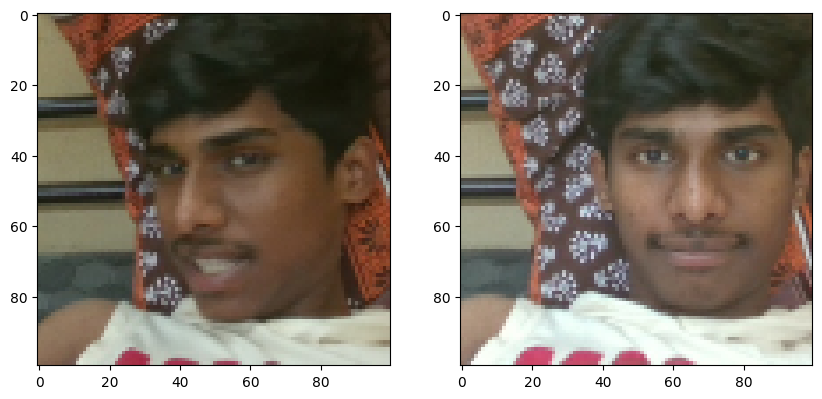

In [76]:
# Set plot size 
plt.figure(figsize=(10,8))

# Set first subplot
plt.subplot(1,2,1)
plt.imshow(test_input[0])

# Set second subplot
plt.subplot(1,2,2)
plt.imshow(test_val[0])

# Renders cleanly
plt.show()

In [77]:
siamese_model.save('siamesemodel.h5')

In [78]:

L1Dist

__main__.L1Dist

In [79]:
model = tf.keras.models.load_model('siamesemodel.h5', 
                                   custom_objects={'L1Dist':L1Dist, 'BinaryCrossentropy':tf.losses.BinaryCrossentropy})

In [80]:
model.predict([test_input, test_val])

array([[0.4980929 ],
       [0.49727824],
       [0.5001436 ],
       [0.49817005],
       [0.49864674],
       [0.498568  ],
       [0.4993565 ],
       [0.4983742 ],
       [0.49963868],
       [0.49665454],
       [0.49781138],
       [0.49960324],
       [0.49768844],
       [0.49840018],
       [0.49911386],
       [0.49825075]], dtype=float32)

In [81]:
model.summary()

Model: "SiameseNetwork"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_img (InputLayer)          [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
validation_img (InputLayer)     [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
embedding (Functional)          (None, 4096)         38960448    input_img[0][0]                  
                                                                 validation_img[0][0]             
__________________________________________________________________________________________________
l1_dist_3 (L1Dist)              (None, 4096)         0           embedding[0][0]     

In [82]:
application_data\verification_images


SyntaxError: unexpected character after line continuation character (4081098762.py, line 1)

In [83]:
os.listdir(os.path.join('application_data', 'verification_images'))


['96f04ae1-dbf0-11ef-a72e-401a582ecf56.jpg',
 '96f7e3ea-dbf0-11ef-ada8-401a582ecf56.jpg',
 '97077177-dbf0-11ef-9063-401a582ecf56.jpg',
 '970ecccf-dbf0-11ef-83bd-401a582ecf56.jpg',
 '97152c37-dbf0-11ef-9c2c-401a582ecf56.jpg',
 '9724f6bb-dbf0-11ef-ad52-401a582ecf56.jpg',
 '9973bd54-dbf0-11ef-a638-401a582ecf56.jpg',
 '99809955-dbf0-11ef-a16a-401a582ecf56.jpg',
 '998fbd49-dbf0-11ef-bb6d-401a582ecf56.jpg',
 '99afd337-dbf0-11ef-b791-401a582ecf56.jpg',
 '99c2cf44-dbf0-11ef-90c8-401a582ecf56.jpg',
 '99c67df1-dbf0-11ef-8c50-401a582ecf56.jpg',
 '99cceaca-dbf0-11ef-8fd9-401a582ecf56.jpg',
 '99de923b-dbf0-11ef-b427-401a582ecf56.jpg',
 '99eb49c4-dbf0-11ef-bcf0-401a582ecf56.jpg',
 '99f621fb-dbf0-11ef-ba19-401a582ecf56.jpg',
 '99fd1d87-dbf0-11ef-b564-401a582ecf56.jpg',
 '9a1b9bcd-dbf0-11ef-89b6-401a582ecf56.jpg',
 '9a2872cb-dbf0-11ef-9c10-401a582ecf56.jpg',
 '9a37b222-dbf0-11ef-af02-401a582ecf56.jpg',
 '9a56fabc-dbf0-11ef-ae73-401a582ecf56.jpg',
 '9a656873-dbf0-11ef-b42b-401a582ecf56.jpg',
 '9a6d1b37

In [84]:
os.path.join('application_data', 'input_image', 'input_image.jpg')


'application_data\\input_image\\input_image.jpg'

In [98]:
for image in os.listdir(os.path.join('application_data', 'verification_images')):
    validation_img = os.path.join('application_data', 'verification_images', image)
    print(validation_img)

application_data\verification_images\96f04ae1-dbf0-11ef-a72e-401a582ecf56.jpg
application_data\verification_images\96f7e3ea-dbf0-11ef-ada8-401a582ecf56.jpg
application_data\verification_images\97077177-dbf0-11ef-9063-401a582ecf56.jpg
application_data\verification_images\970ecccf-dbf0-11ef-83bd-401a582ecf56.jpg
application_data\verification_images\97152c37-dbf0-11ef-9c2c-401a582ecf56.jpg
application_data\verification_images\9724f6bb-dbf0-11ef-ad52-401a582ecf56.jpg
application_data\verification_images\9973bd54-dbf0-11ef-a638-401a582ecf56.jpg
application_data\verification_images\99809955-dbf0-11ef-a16a-401a582ecf56.jpg
application_data\verification_images\998fbd49-dbf0-11ef-bb6d-401a582ecf56.jpg
application_data\verification_images\99afd337-dbf0-11ef-b791-401a582ecf56.jpg
application_data\verification_images\99c2cf44-dbf0-11ef-90c8-401a582ecf56.jpg
application_data\verification_images\99c67df1-dbf0-11ef-8c50-401a582ecf56.jpg
application_data\verification_images\99cceaca-dbf0-11ef-8fd9-401

In [99]:
def verify(model, detection_threshold, verification_threshold):
    # Build results array
    results = []
    for image in os.listdir(os.path.join('application_data', 'verification_images')):
        input_img = preprocess(os.path.join('application_data', 'input_image', 'input_image.jpg'))
        validation_img = preprocess(os.path.join('application_data', 'verification_images', image))
        
        # Make Predictions 
        result = model.predict(list(np.expand_dims([input_img, validation_img], axis=1)))
        results.append(result)
    
    # Detection Threshold: Metric above which a prediciton is considered positive 
    detection = np.sum(np.array(results) > detection_threshold)
    
    # Verification Threshold: Proportion of positive predictions / total positive samples 
    verification = detection / len(os.listdir(os.path.join('application_data', 'verification_images'))) 
    verified = verification > verification_threshold
    
    return results, verified

In [ ]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()
    frame = frame[120:120+250,200:200+250, :]
    
    cv2.imshow('Verification', frame)
    
    # Verification trigger
    if cv2.waitKey(10) & 0xFF == ord('v'):
        # Save input image to application_data/input_image folder 
        cv2.imwrite(os.path.join('application_data', 'input_image', 'input_image.jpg'), frame)
        # Run verification
        results, verified = verify(model, 0.5, 0.5)
        print(verified)
    
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()